# XGBoost: Credit Risk Scoring & Credit Limit Prediction

**Objective:** Classify customer risk and predict credit limits
- **Task 1:** Risk Classification (High/Low)
- **Task 2:** Credit Limit Regression (USD amount)

In [8]:
import warnings
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier, XGBRegressor
import joblib
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('outputs', exist_ok=True)


## Dataset Generation

In [9]:

def generate_realistic_warehouse_dataset(n_samples=1200):
    rng = np.random.default_rng(42)
    
    # 1. تەمەنی دوکان (بە ساڵ)
    shop_age_years = rng.integers(1, 15, size=n_samples)
    
    # 2. Recency: چەند ڕۆژە کاڵای نەبردووە (زۆربەیان لە 1 بۆ 45 ڕۆژ دەبن)
    days_since_last_order = rng.integers(1, 60, size=n_samples)
    
    # 3. Frequency & Velocity: مانگانە چەند وەسڵی هەیە (1 بۆ 15 وەسڵ)
    order_freq_per_month = rng.uniform(1.0, 15.0, size=n_samples).round(1)
    
    # 4. تێکڕای بەهای وەسڵ (مامناوەند 20$ بۆ 500$ کە زۆر واقیعییە بۆ دوکانەکان)
    avg_invoice_value = rng.uniform(20, 500, size=n_samples).round(-1)
    
    # 5. Monetary: کۆی قەبارەی مامەڵەکان
    total_trade_volume = (order_freq_per_month * 12 * shop_age_years * avg_invoice_value).round(-1)
    
    # 6. Payment History: ڕێژەی وەسڵە نەدراوەکان لە کۆی وەسڵەکان
    unpaid_invoice_ratio = rng.beta(a=1, b=5, size=n_samples).round(3)
    
    # 7. قەرزی ئێستا پێوانە دەکرێت لەسەر بنەمای قەبارەی بازرگانی و ڕێژەی وەسڵە نەدراوەکان
    current_debt = (total_trade_volume * unpaid_invoice_ratio * rng.uniform(0.5, 1.2, size=n_samples)).round(-1)
    
    # 8. Debt to Volume Ratio (ڕێژەی قەرز بۆ کۆی مامەڵە)
    debt_to_volume_ratio = np.where(total_trade_volume > 0, current_debt / total_trade_volume, 0).round(3)
    
    # 9. مێژووی دواکەوتنی پارەدان (Late Payment History)
    late_payment_history = rng.poisson(lam=1.5, size=n_samples)
    
    # --- لۆژیکی زانستی بۆ ئاستی مەترسی (Risk Score) ---
    risk_logit = (-3.5 
                  + 9.0 * debt_to_volume_ratio          
                  + 6.0 * unpaid_invoice_ratio          
                  + 0.5 * late_payment_history          
                  + 0.03 * days_since_last_order        
                  - 0.25 * shop_age_years                
                  - 0.1 * order_freq_per_month         
                  + rng.normal(0, 0.4, n_samples))
    
    risk_prob = 1 / (1 + np.exp(-risk_logit))
    high_risk = (rng.uniform(size=n_samples) < risk_prob).astype(int)
    
    # --- لۆژیکی سنووری قەرز (Credit Limit) بە بڕێکی واقیعی ---
    risk_multiplier = np.where(high_risk == 1, 0.3, 1.2)
    # بیس لیمیتەکە لە نێوان 100$ بۆ 2500$ دەبێت
    base_limit = (avg_invoice_value * order_freq_per_month * 0.5) + (shop_age_years * 50)
    
    credit_limit = (base_limit * risk_multiplier) - (current_debt * 0.2) + rng.normal(0, 50, n_samples)
    # کەمترین قەرز 100$ دەبێت وە زۆرترینیش 2,000$ (واتە دوو دەفتەر) دەبێت
    credit_limit = np.clip(credit_limit, 100, 2000).round(-1) 
    
    return pd.DataFrame({
        'Shop_Age_Years': shop_age_years,
        'Days_Since_Last_Order': days_since_last_order,
        'Order_Freq_Per_Month': order_freq_per_month,
        'Average_Invoice_Value': avg_invoice_value,
        'Total_Trade_Volume': total_trade_volume,
        'Unpaid_Invoice_Ratio': unpaid_invoice_ratio,
        'Debt_To_Volume_Ratio': debt_to_volume_ratio,
        'Late_Payment_History': late_payment_history,
        'High_Risk': high_risk,
        'Credit_Limit': credit_limit,
    })

df = generate_realistic_warehouse_dataset(1200)

# --- SMOTE OVERSAMPLING ---
smote = SMOTE(random_state=42)
X_temp = df.drop(columns=['High_Risk'])
y_temp = df['High_Risk']
X_res, y_res = smote.fit_resample(X_temp, y_temp)
df = pd.DataFrame(X_res, columns=X_temp.columns)
df['High_Risk'] = y_res

df.to_csv('outputs/erbil_warehouse_dataset.csv', index=False)
print(f'Dataset Shape: {df.shape} | Classes: {dict(df["High_Risk"].value_counts())}')

Dataset Shape: (1910, 10) | Classes: {1: np.int64(955), 0: np.int64(955)}


## Preprocessing & Split

In [10]:

features_list = [
    'Shop_Age_Years', 'Days_Since_Last_Order', 'Order_Freq_Per_Month', 
    'Average_Invoice_Value', 'Total_Trade_Volume', 'Unpaid_Invoice_Ratio', 
    'Debt_To_Volume_Ratio', 'Late_Payment_History'
]

X_clf = df[features_list].values
X_reg = df[features_list + ['High_Risk']].values
y_risk = df['High_Risk'].values
y_credit = df['Credit_Limit'].values

X_train_clf, X_test_clf, X_train_reg, X_test_reg, y_risk_train, y_risk_test, y_credit_train, y_credit_test = train_test_split(
    X_clf, X_reg, y_risk, y_credit, test_size=0.20, random_state=42, stratify=y_risk)

scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_scaled = scaler_clf.transform(X_test_clf)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

X_train_clf_split, X_val_clf, y_risk_train_split, y_risk_val = train_test_split(
    X_train_scaled, y_risk_train, test_size=0.10, random_state=42, stratify=y_risk_train)

X_train_reg_split, X_val_reg, y_credit_train_split, y_credit_val = train_test_split(
    X_train_reg_scaled, y_credit_train, test_size=0.10, random_state=42)


## Model Training

In [11]:

print("\n=============================================")
print("🚀 OPTIMIZING RISK CLASSIFIER (XGBoost)")
print("=============================================")

xgb_clf_base = XGBClassifier(n_estimators=400, eval_metric='auc', early_stopping_rounds=40, random_state=42, verbosity=0)
param_grid_clf = {
    'max_depth': [3, 4, 5, 6], 'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [2, 4, 6], 'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9], 'alpha': [0.1, 0.5, 1.0], 'lambda': [1.0, 2.0, 5.0]
}
clf_search = RandomizedSearchCV(xgb_clf_base, param_distributions=param_grid_clf, n_iter=20, scoring='roc_auc', cv=5, verbose=1, random_state=42, n_jobs=-1)
clf_search.fit(X_train_clf_split, y_risk_train_split, eval_set=[(X_val_clf, y_risk_val)], verbose=False)
xgb_clf = clf_search.best_estimator_

print("\n=============================================")
print("🚀 OPTIMIZING CREDIT LIMIT REGRESSOR (XGBoost)")
print("=============================================")

xgb_reg_base = XGBRegressor(n_estimators=400, eval_metric='rmse', early_stopping_rounds=40, random_state=42, verbosity=0)
param_grid_reg = param_grid_clf.copy()
reg_search = RandomizedSearchCV(xgb_reg_base, param_distributions=param_grid_reg, n_iter=20, scoring='r2', cv=5, verbose=1, random_state=42, n_jobs=-1)
reg_search.fit(X_train_reg_split, y_credit_train_split, eval_set=[(X_val_reg, y_credit_val)], verbose=False)
xgb_reg = reg_search.best_estimator_

# پاشەکەوتکردن
joblib.dump(xgb_clf, 'outputs/risk_model_improved.joblib')
joblib.dump(xgb_reg, 'outputs/limit_model_improved.joblib')
joblib.dump(scaler_clf, 'outputs/scaler_clf_improved.joblib')
joblib.dump(scaler_reg, 'outputs/scaler_reg_improved.joblib')


🚀 OPTIMIZING RISK CLASSIFIER (XGBoost)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🚀 OPTIMIZING CREDIT LIMIT REGRESSOR (XGBoost)
Fitting 5 folds for each of 20 candidates, totalling 100 fits


['outputs/scaler_reg_improved.joblib']

## Results JSON & CSV & Plot

In [12]:

y_clf_train_pred = xgb_clf.predict(X_train_scaled)
y_clf_train_prob = xgb_clf.predict_proba(X_train_scaled)[:, 1]
y_reg_train_pred = xgb_reg.predict(X_train_reg_scaled)

y_risk_pred = xgb_clf.predict(X_test_scaled)
y_risk_proba = xgb_clf.predict_proba(X_test_scaled)[:, 1]
y_credit_pred = xgb_reg.predict(X_test_reg_scaled)

pd.DataFrame({
    'Actual_Risk': y_risk_test, 'Predicted_Risk': y_risk_pred, 'Risk_Probability': y_risk_proba,
    'Actual_Credit_Limit': y_credit_test, 'Predicted_Credit_Limit': y_credit_pred,
    'Prediction_Error': np.abs(y_credit_test - y_credit_pred)
}).to_csv('outputs/credit_risk_predictions.csv', index=False)

metrics_data = {
    "CLF_TRAIN": {
        "accuracy": float(accuracy_score(y_risk_train, y_clf_train_pred)),
        "auc_roc": float(roc_auc_score(y_risk_train, y_clf_train_prob)),
        "f1": float(f1_score(y_risk_train, y_clf_train_pred, zero_division=0))
    },
    "CLF": {
        "accuracy": float(accuracy_score(y_risk_test, y_risk_pred)),
        "auc_roc": float(roc_auc_score(y_risk_test, y_risk_proba)),
        "f1": float(f1_score(y_risk_test, y_risk_pred, zero_division=0))
    },
    "REG_TRAIN": {
        "rmse": float(np.sqrt(mean_squared_error(y_credit_train, y_reg_train_pred))),
        "mae": float(mean_absolute_error(y_credit_train, y_reg_train_pred)),
        "r2": float(r2_score(y_credit_train, y_reg_train_pred))
    },
    "REG": {
        "rmse": float(np.sqrt(mean_squared_error(y_credit_test, y_credit_pred))),
        "mae": float(mean_absolute_error(y_credit_test, y_credit_pred)),
        "r2": float(r2_score(y_credit_test, y_credit_pred))
    },
    "FEAT_NAMES": features_list,
    "FEAT_IMP": xgb_reg.feature_importances_.tolist()
}

with open("outputs/model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_data, f, indent=4)

# وێنەی یەکەم
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost: Risk Scoring & Credit Limit Prediction', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_risk_test, y_risk_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Risk', 'High Risk']).plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Risk Classification', fontweight='bold')

axes[1].scatter(y_credit_test, y_credit_pred, alpha=0.5, s=30, color='#1f77b4', edgecolors='white', linewidth=0.5)
lims = [min(y_credit_test.min(), y_credit_pred.min()), max(y_credit_test.max(), y_credit_pred.max())]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Credit Limit ($)', fontweight='bold')
axes[1].set_ylabel('Predicted Credit Limit ($)', fontweight='bold')
axes[1].set_title(f"Credit Limit Prediction (R² = {metrics_data['REG']['r2']:.4f})", fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/credit_risk_scoring_results.png', dpi=150, bbox_inches='tight')
plt.close()

# وێنەی دووەم
df_imp = pd.DataFrame({'Feature': features_list, 'Importance': xgb_clf.feature_importances_}).sort_values(by='Importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(df_imp['Feature'], df_imp['Importance'], color='#34d399', edgecolor='black')
plt.title('Feature Importance (Risk Model) - Advanced RFM', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150)
plt.close()

print("\n✅ داتای واقیعی دروستکرا و ئەنجامەکان بە سەرکەوتوویی بۆ وێبسایتەکە نێردرا.")


✅ داتای واقیعی دروستکرا و ئەنجامەکان بە سەرکەوتوویی بۆ وێبسایتەکە نێردرا.


In [13]:
# Evaluate on training set to check for overfitting
y_risk_train_pred = xgb_clf.predict(X_train_scaled)
y_risk_train_proba = xgb_clf.predict_proba(X_train_scaled)[:, 1]

train_acc = accuracy_score(y_risk_train, y_risk_train_pred)
train_f1 = f1_score(y_risk_train, y_risk_train_pred)
train_auc = roc_auc_score(y_risk_train, y_risk_train_proba)

print('TRAINING CLASSIFICATION (Risk Scoring)')
print('='*40)
print(f'Accuracy : {train_acc:.4f} | F1-Score : {train_f1:.4f}')
print(f'ROC-AUC  : {train_auc:.4f}\n')

y_credit_train_pred = xgb_reg.predict(X_train_reg_scaled)

train_mse = mean_squared_error(y_credit_train, y_credit_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_credit_train, y_credit_train_pred)
train_r2 = r2_score(y_credit_train, y_credit_train_pred)

print('TRAINING REGRESSION (Credit Limit Prediction)')
print('='*40)
print(f'MSE  : ${train_mse:,.2f}')
print(f'RMSE : ${train_rmse:,.2f}')
print(f'MAE  : ${train_mae:,.2f}')
print(f'R²   : {train_r2:.4f}')

# Define test metrics
acc = accuracy_score(y_risk_test, y_risk_pred)
auc = roc_auc_score(y_risk_test, y_risk_proba)
r2 = r2_score(y_credit_test, y_credit_pred)

print('\nOVERFITTING CHECK:')
print('='*40)
print('If training metrics are significantly better than test metrics, the model may be overfitting.')
print(f'Classification - Train Acc(F1): {train_acc:.4f} vs Test Acc(F1): {acc:.4f} (Gap: {train_acc - acc:.4f})')
print(f'Classification - Train AUC: {train_auc:.4f} vs Test AUC: {auc:.4f} (Gap: {train_auc - auc:.4f})')
print(f'Regression - Train R²: {train_r2:.4f} vs Test R²: {r2:.4f} (Gap: {train_r2 - r2:.4f})')

TRAINING CLASSIFICATION (Risk Scoring)
Accuracy : 0.9764 | F1-Score : 0.9765
ROC-AUC  : 0.9961

TRAINING REGRESSION (Credit Limit Prediction)
MSE  : $1,982.28
RMSE : $44.52
MAE  : $12.91
R²   : 0.9877

OVERFITTING CHECK:
If training metrics are significantly better than test metrics, the model may be overfitting.
Classification - Train Acc(F1): 0.9764 vs Test Acc(F1): 0.9005 (Gap: 0.0759)
Classification - Train AUC: 0.9961 vs Test AUC: 0.9621 (Gap: 0.0340)
Regression - Train R²: 0.9877 vs Test R²: 0.9442 (Gap: 0.0435)


## Visualization

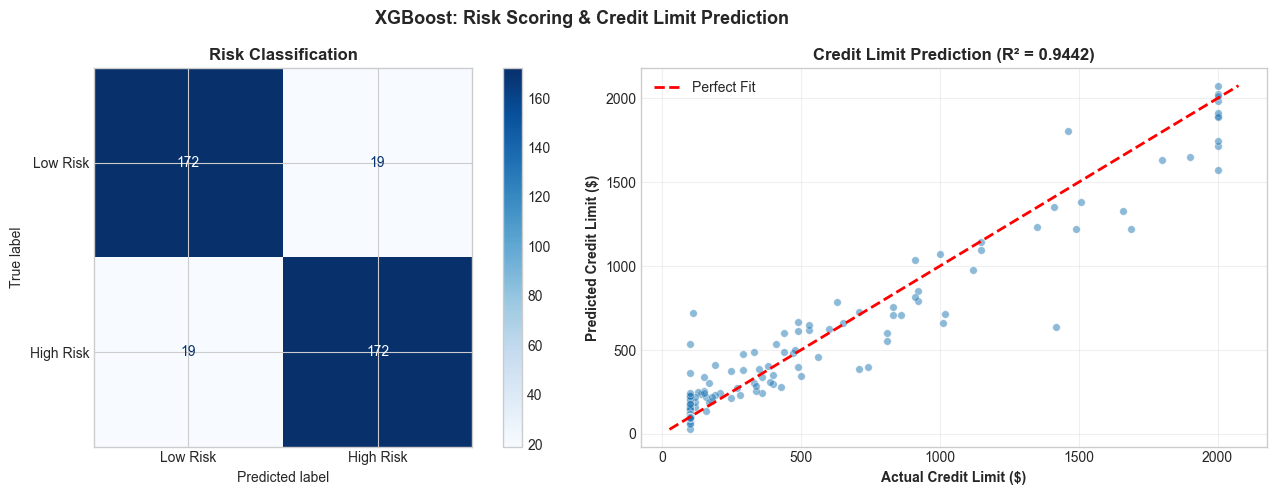

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost: Risk Scoring & Credit Limit Prediction', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_risk_test, y_risk_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Risk', 'High Risk']).plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Risk Classification', fontweight='bold')

axes[1].scatter(y_credit_test, y_credit_pred, alpha=0.5, s=30, color='#1f77b4', edgecolors='white', linewidth=0.5)
lims = [min(y_credit_test.min(), y_credit_pred.min()), max(y_credit_test.max(), y_credit_pred.max())]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Credit Limit ($)', fontweight='bold')
axes[1].set_ylabel('Predicted Credit Limit ($)', fontweight='bold')
axes[1].set_title(f'Credit Limit Prediction (R² = {r2:.4f})', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/credit_risk_scoring_results.png', dpi=150, bbox_inches='tight')
plt.show()